## **INSTALLATION DES LIBRAIRIES**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import missingno as msno
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from statsmodels.tools.tools import add_constant
from sklearn.linear_model import LinearRegression
from scipy.stats import skew, kurtosis, jarque_bera
from sklearn.model_selection import train_test_split
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score
plt.style.use('ggplot') # Appliquer le style 'ggplot' à Matplotlib

# **PARTIE I : CHARGEMENT ET PREPARATION DES DONNEES**

1. Chargement et aperçu des donnees

1.1. Importation du dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Classeur1.xlsx to Classeur1 (1).xlsx


In [ ]:
import io
import pandas as pd

df = pd.read_excel(io.BytesIO(uploaded['Classeur1 (1).xlsx']))

1.2. Visualiser les premieres lignes du DataFrame pour inspection

In [ ]:
df.head()

,Country Name,Country Code,1960,1961,1962,1963,1964,1965,1966,1967,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,...,135.0,NaN,NaN,NaN,132.0,132.0,132.0,NaN,NaN,NaN
1,NaN,AFE,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,...,66.0,64.0,64.0,65.0,68.0,70.0,75.0,78.0,81.0,NaN
2,Afghanistan,AFG,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,...,58.0,62.0,67.0,60.0,60.0,58.0,57.0,NaN,NaN,NaN
3,NaN,AFW,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,...,83.0,83.0,81.0,88.0,91.0,97.0,95.0,102.0,101.0,NaN
4,Angola,AGO,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,...,49.0,45.0,44.0,42.0,46.0,44.0,44.0,67.0,NaN,NaN


1.3. Infos

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 67 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  264 non-null    object 
 1   Country Code  266 non-null    object 
 2   1960          248 non-null    float64
 3   1961          0 non-null      float64
 4   1962          0 non-null      float64
 5   1963          0 non-null      float64
 6   1964          0 non-null      float64
 7   1965          248 non-null    float64
 8   1966          0 non-null      float64
 9   1967          0 non-null      float64
 10  1968          0 non-null      float64
 11  1969          0 non-null      float64
 12  1970          248 non-null    float64
 13  1971          0 non-null      float64
 14  1972          0 non-null      float64
 15  1973          0 non-null      float64
 16  1974          0 non-null      float64
 17  1975          248 non-null    float64
 18  1976          248 non-null    

In [ ]:
df = pd.melt(df,id_vars=['Country Name', 'Country Code'],
                var_name='Year',
                value_name='Suscriber')
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df.head()

,Country Name,Country Code,Year,Suscriber
0,Aruba,ABW,1960,0.0
1,NaN,AFE,1960,0.0
2,Afghanistan,AFG,1960,0.0
3,NaN,AFW,1960,0.0
4,Angola,AGO,1960,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17290 entries, 0 to 17289
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  17160 non-null  object 
 1   Country Code  17290 non-null  object 
 2   Year          17290 non-null  int64  
 3   Suscriber     12688 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 540.4+ KB


# **PARTIE II : APUREMENT DES DONNEES**

2. Traitement des valeurs manquantes

2.1. Visualisation des valeurs manquantes

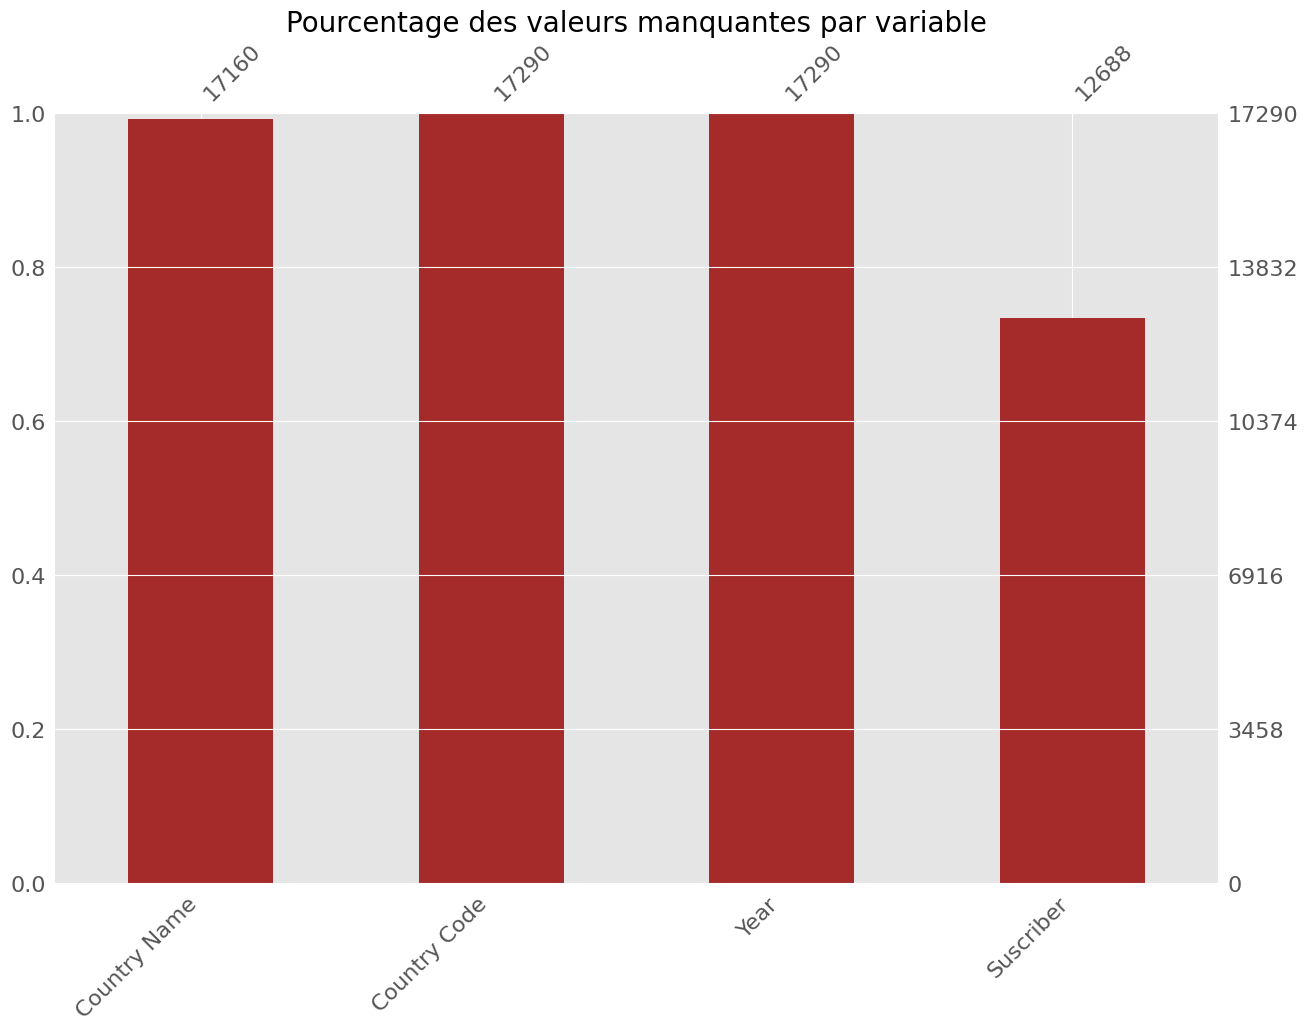

In [ ]:
# Visualiser le pourcentage de valeurs manquantes pour chaque colonne
msno.bar(df, color='brown', figsize=(15, 10))

# Ajouter un titre
plt.title('Pourcentage des valeurs manquantes par variable', fontsize=20)

# Afficher le graphique
plt.show()

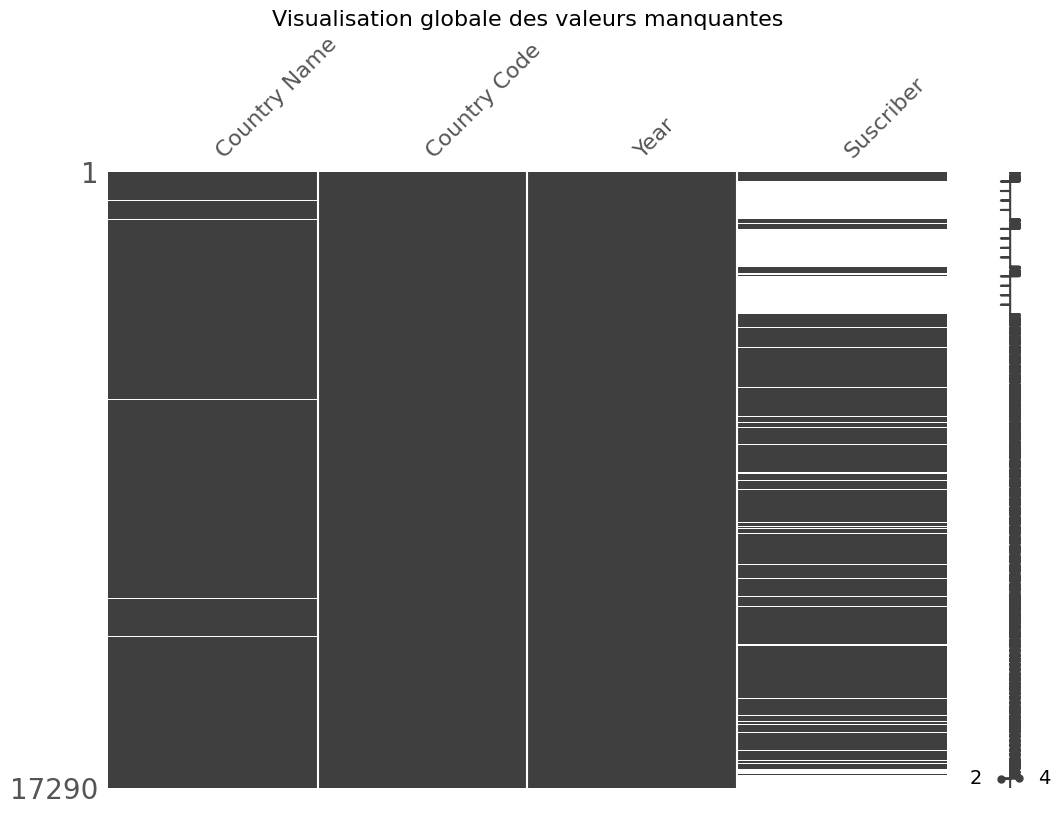

In [ ]:
# Visualiser les valeurs manquantes globalement
msno.matrix(df, figsize=(12, 8))

# Ajouter un titre pour la visualisation globale
plt.title('Visualisation globale des valeurs manquantes', fontsize=16)

# Afficher le graphique
plt.show()

2.2. Imputation des variables manquantes

In [ ]:
from sklearn.impute import KNNImputer
import pandas as pd
import numpy as np

# Colonnes à imputer (exclure 'Country Name' et 'Country Code')
columns_to_impute = [col for col in df.columns if col not in ['Country Name', 'Country Code']]

# 1) Préparer une version nettoyée qui servira à l'imputation
#    On remplace séparateurs courants de milliers et symboles qui empêchent la conversion.
df_for_impute = df[columns_to_impute].replace({
    r',': '',      # "1,234" -> "1234"
    r'\s+': '',    # "1 234" -> "1234"
    r'%': ''       # "12%" -> "12" si vous voulez traiter les pourcentages (adapter si besoin)
}, regex=True).copy()

# Convertir en numérique (coerce pour mettre NaN si impossible)
df_for_impute = df_for_impute.apply(lambda s: pd.to_numeric(s, errors='coerce'))


# 2) Exclure colonnes entièrement NaN (imputation impossible)
cols_entirely_nan = df_for_impute.columns[df_for_impute.isnull().all()].tolist()
print(f"\nColonnes entièrement NaN (exclues) : {cols_entirely_nan}")

columns_for_knn = [c for c in df_for_impute.columns if c not in cols_entirely_nan]

if not columns_for_knn:
    print("\nAucune colonne disponible pour KNN imputer après exclusion.")
else:
    # 3) Appliquer KNNImputer sur la copie numérique
    imputer = KNNImputer(n_neighbors=5)
    imputed_array = imputer.fit_transform(df_for_impute[columns_for_knn])
    df_imputed = pd.DataFrame(imputed_array, index=df.index, columns=columns_for_knn)

    # 4) Ne remplir QUE les valeurs qui étaient NaN dans la version nettoyée (i.e. non-convertibles / manquantes)
    for col in columns_for_knn:
        # original_clean_numeric : version nettoyée et convertie du DataFrame d'origine
        original_clean_numeric = pd.to_numeric(df[col].replace({r',':'', r'\s+':'', r'%':''}, regex=True), errors='coerce')
        mask_missing = original_clean_numeric.isna()  # True pour lignes à remplir

        # Remplir uniquement les lignes manquantes
        if mask_missing.any():
            df.loc[mask_missing, col] = df_imputed.loc[mask_missing, col].values

    # 5) Afficher résultat et vérifier s'il reste des NaN dans les colonnes imputées
    #print("\nAperçu après imputation (colonnes imputées) :")
    #display(df[columns_for_knn].head())



Colonnes entièrement NaN (exclues) : []


 2.3. Visualisation des valeurs manquantes traitées

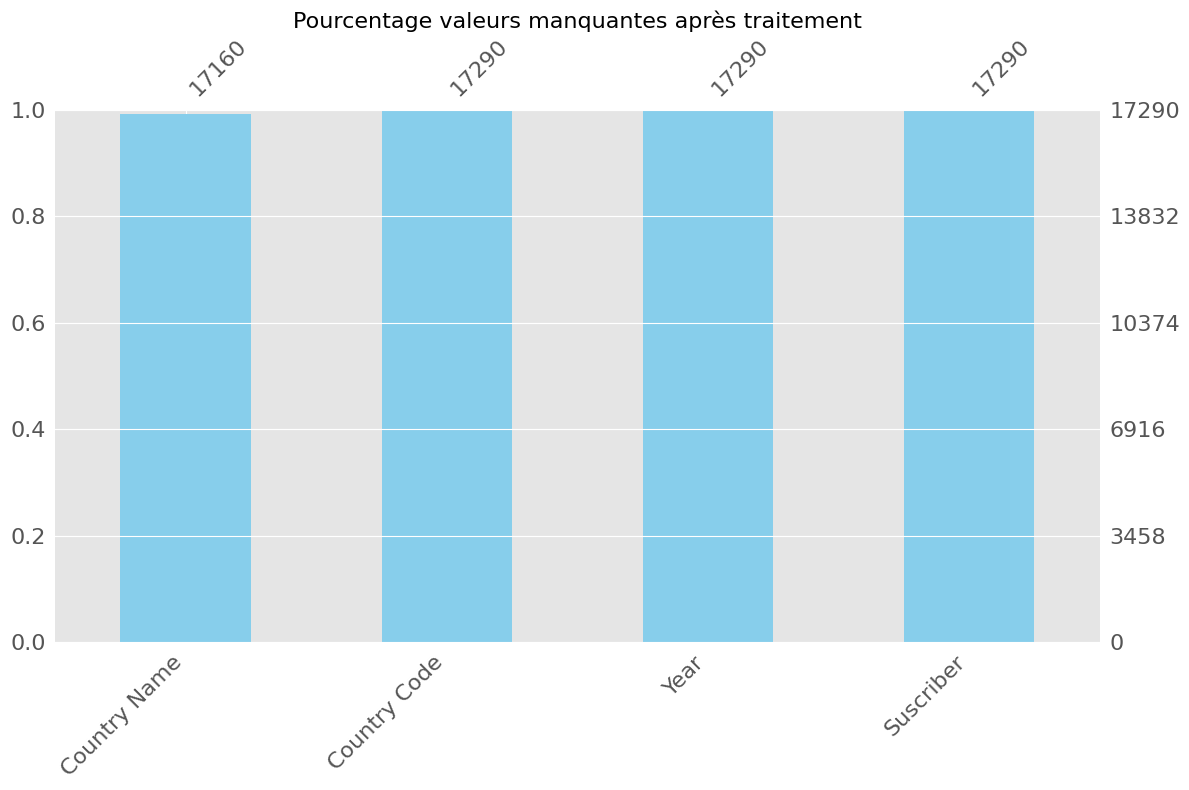

In [ ]:
# Visualiser des valeurs manquantes traitées
msno.bar(df, color='skyblue', figsize=(12, 8))

# Ajouter un titre
plt.title('Pourcentage valeurs manquantes après traitement', fontsize=16)

# Afficher le graphique
plt.tight_layout()
plt.show()

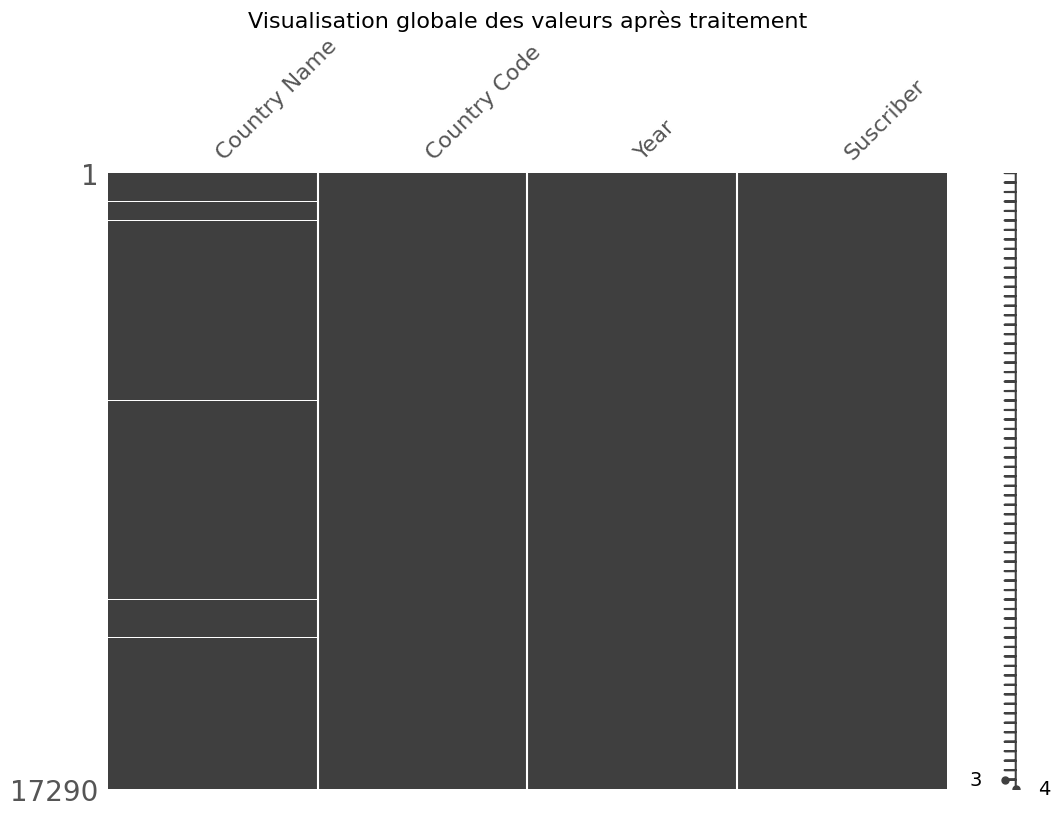

In [ ]:
# Visualiser les valeurs manquantes globalement
msno.matrix(df, figsize=(12, 8))

# Ajouter un titre pour la visualisation globale
plt.title('Visualisation globale des valeurs après traitement', fontsize=16)

# Afficher le graphique
plt.show()

In [ ]:
# Remove columns for years 1960 to 1994
#years_to_drop = [str(year) for year in range(1960, 1995)]
#columns_to_keep = ['Country Name', 'Country Code'] + [col for col in df.columns if col not in years_to_drop and col not in ['Country Name', 'Country Code']]
#df = df[columns_to_keep]

Remove rows 1960 to 1994

In [ ]:
df = df[df['Year'] >= 1995]

# Remove rows with 'Country Code' 'AFE' or 'AFW'
df = df[~df['Country Code'].isin(['AFE', 'AFW'])]

print("\nAperçu après imputation (colonnes imputées) :")
df.head()


Aperçu après imputation (colonnes imputées) :


,Country Name,Country Code,Year,Suscriber
9310,Aruba,ABW,1995,2.0
9312,Afghanistan,AFG,1995,0.0
9314,Angola,AGO,1995,0.0
9315,Albanie,ALB,1995,0.0
9316,Andorre,AND,1995,4.0


3. Traitement des valeurs abberantes et/ ou extremes

3.1. Selectionner uniquement les colonnes numériques

In [ ]:
# Sélectionner toutes les colonnes numériques sauf Year
df_numeric = df.select_dtypes(include=['number']).drop(columns=['Year'], errors='ignore')
df_numeric



,Suscriber
9310,2.0
9312,0.0
9314,0.0
9315,0.0
9316,4.0
...,...
17284,107.4
17286,107.4
17287,107.4
17288,107.4


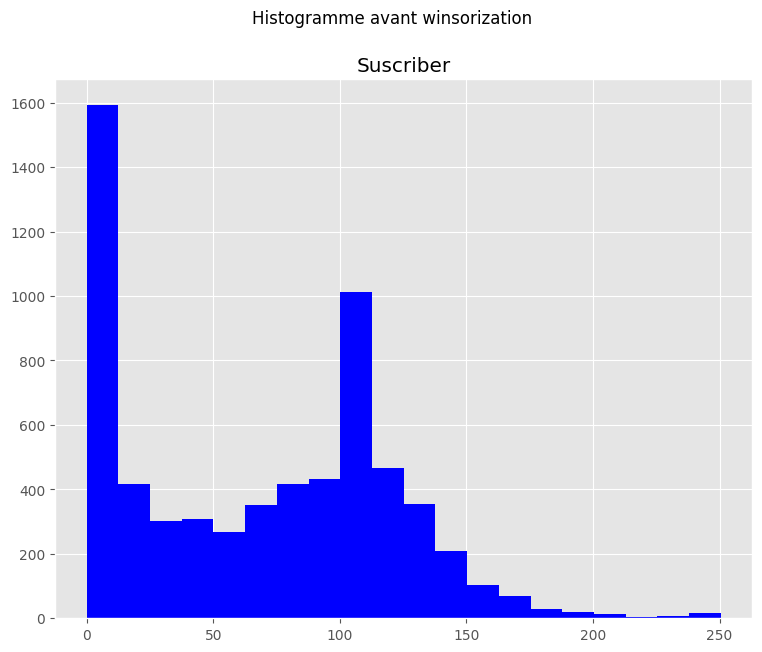

In [ ]:
# Histogramme pour chaque colonne avant winzorisation
df_numeric.hist(bins=20, figsize=(9, 7), color = 'b')
plt.suptitle("Histogramme avant winsorization")
plt.show()

In [ ]:
# Afficher les statistiques descriptives avant winzorisation
df_numeric.describe()

,Suscriber
count,6390.000000
mean,68.142973
std,52.197708
min,0.000000
25%,13.000000
50%,74.000000
75%,107.850000
max,250.500000


3.2. Boxplot pour chaque colonne numerique

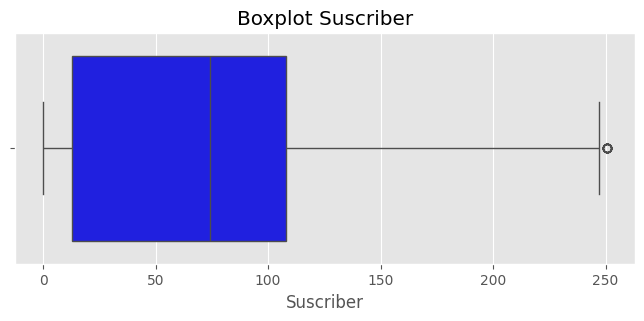

In [ ]:
# Créer un boxplot
for column in df_numeric.columns:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df_numeric[column], color='b')
    plt.title(f'Boxplot {column}')
    plt.xlabel(column)
    plt.show()

3.3. Traitement des valeurs abberantes et/ ou extremes

In [ ]:
# Calculer les quartiles et l'IQR pour chaque colonne
Q1 = df_numeric.quantile(0.25)
Q3 = df_numeric.quantile(0.75)
IQR = Q3 - Q1

# Définir les bornes de Winsorization
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Appliquer la Winsorization sur chaque colonne numérique
df_winzorized = df_numeric.apply(
     lambda x: x.clip(lower=lower_bound[x.name],
                      upper=upper_bound[x.name]),
                      axis=0
                     )

# Remplacer les colonnes numériques dans le DataFrame d'origine
df_numeric.update(df_winzorized)
df.update(df_winzorized)

In [ ]:
(df_numeric < lower_bound) | (df_numeric > upper_bound)

In [ ]:
# Vérifier les valeurs qui dépassent les bornes définies
outliers_lower = df_numeric[df_numeric < lower_bound]
outliers_upper = df_numeric[df_numeric > upper_bound]

# Vérifier si des valeurs aberrantes sont présentes
print("Valeurs inférieures à la borne inférieure :")
outliers_lower

In [ ]:
print("Valeurs supérieures à la borne supérieure :")
outliers_upper

3.4. Boxplot pour chaque colonne numerique apres traitement

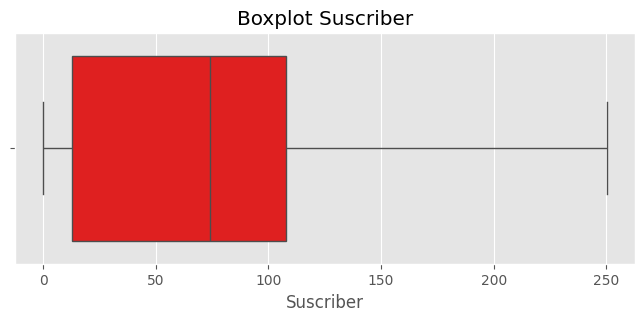

In [ ]:
# Creer un boxplot pour chaque colonne numerique dans un graphique separe
for column in df_numeric.columns:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df_numeric[column], color='r')
    plt.title(f'Boxplot {column}')
    plt.xlabel(column)
    plt.show()

In [ ]:
# Afficher les statistiques descriptives apres traitement
df_numeric.describe()

,Suscriber
count,6390.000000
mean,68.142152
std,52.194840
min,0.000000
25%,13.000000
50%,74.000000
75%,107.850000
max,250.125000


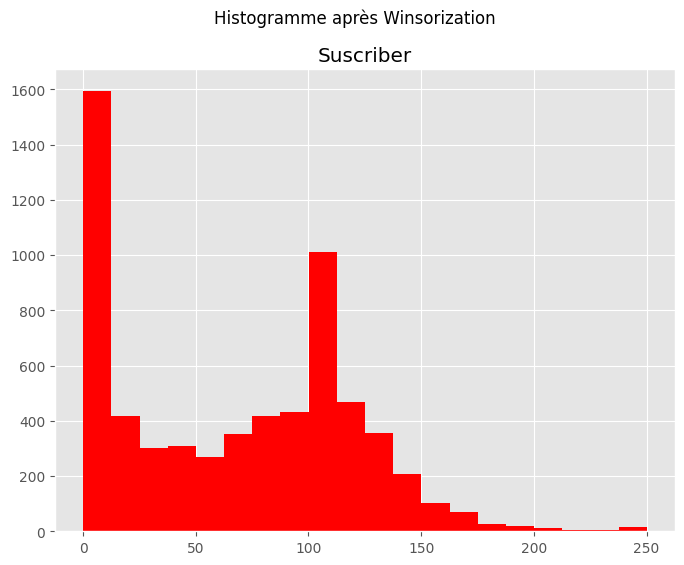

In [ ]:
# Histogramme pour chaque colonne apres Winsorization
df_numeric.hist(bins=20, figsize=(8, 6), color = 'r')
plt.suptitle("Histogramme après Winsorization")
plt.show()

## Graphiques

In [ ]:
!pip install pycountry-convert

In [ ]:
from pycountry_convert import country_alpha2_to_continent_code, convert_continent_code_to_continent_name

def get_continent(country_code):
    """
    Converts a country code (alpha-2) to its continent name.

    Args:
        country_code: The alpha-2 country code.

    Returns:
        The continent name or None if the country code is invalid or not found.
    """
    try:
        continent_code = country_alpha2_to_continent_code(country_code)
        continent_name = convert_continent_code_to_continent_name(continent_code)
        return continent_name
    except (KeyError, TypeError):
        return None

# Test the function with a few country codes
print(get_continent('US'))
print(get_continent('CN'))
print(get_continent('IND')) # This should return None as it's not an alpha-2 code
print(get_continent('AFG')) # This should return None as it's not an alpha-2 code

North America
Asia
None
None


In [ ]:
# Apply the get_continent function to create the 'Continent' column
df['Continent'] = df['Country Code'].apply(get_continent)

# Check for rows where 'Continent' is None and investigate
none_continent_rows = df[df['Continent'].isnull()]
print("\nRows with no continent mapping:")
none_continent_rows.head()



Rows with no continent mapping:


,Country Name,Country Code,Year,Suscriber,Continent
9310,Aruba,ABW,1995,2.0,None
9312,Afghanistan,AFG,1995,0.0,None
9314,Angola,AGO,1995,0.0,None
9315,Albanie,ALB,1995,0.0,None
9316,Andorre,AND,1995,4.0,None


In [ ]:
# Investigate the unique values in the 'Country Code' column
print("Unique values in 'Country Code' column:")
print(df['Country Code'].unique())

# Check the data types of the 'Country Code' column
print("\nData type of 'Country Code' column:")
print(df['Country Code'].dtype)

# Re-examine the get_continent function and its expected input
# The pycountry-convert library expects alpha-2 country codes.
# Let's check if the country codes in the DataFrame are indeed alpha-2 codes.
# A simple check is to look at the length of the codes. Alpha-2 codes are 2 characters long.
print("\nLength of country codes:")
print(df['Country Code'].str.len().value_counts())


Unique values in 'Country Code' column:
['ABW' 'AFG' 'AGO' 'ALB' 'AND' 'ARB' 'ARE' 'ARG' 'ARM' 'ASM' 'ATG' 'AUS'
 'AUT' 'AZE' 'BDI' 'BEL' 'BEN' 'BFA' 'BGD' 'BGR' 'BHR' 'BHS' 'BIH' 'BLR'
 'BLZ' 'BMU' 'BOL' 'BRA' 'BRB' 'BRN' 'BTN' 'BWA' 'CAF' 'CAN' 'CEB' 'CHE'
 'CHI' 'CHL' 'CHN' 'CIV' 'CMR' 'COD' 'COG' 'COL' 'COM' 'CPV' 'CRI' 'CSS'
 'CUB' 'CUW' 'CYM' 'CYP' 'CZE' 'DEU' 'DJI' 'DMA' 'DNK' 'DOM' 'DZA' 'EAP'
 'EAR' 'EAS' 'ECA' 'ECS' 'ECU' 'EGY' 'EMU' 'ERI' 'ESP' 'EST' 'ETH' 'EUU'
 'FCS' 'FIN' 'FJI' 'FRA' 'FRO' 'FSM' 'GAB' 'GBR' 'GEO' 'GHA' 'GIB' 'GIN'
 'GMB' 'GNB' 'GNQ' 'GRC' 'GRD' 'GRL' 'GTM' 'GUM' 'GUY' 'HIC' 'HKG' 'HND'
 'HPC' 'HRV' 'HTI' 'HUN' 'IBD' 'IBT' 'IDA' 'IDB' 'IDN' 'IDX' 'IMN' 'IND'
 'INX' 'IRL' 'IRN' 'IRQ' 'ISL' 'ISR' 'ITA' 'JAM' 'JOR' 'JPN' 'KAZ' 'KEN'
 'KGZ' 'KHM' 'KIR' 'KNA' 'KOR' 'KWT' 'LAC' 'LAO' 'LBN' 'LBR' 'LBY' 'LCA'
 'LCN' 'LDC' 'LIC' 'LIE' 'LKA' 'LMC' 'LMY' 'LSO' 'LTE' 'LTU' 'LUX' 'LVA'
 'MAC' 'MAF' 'MAR' 'MCO' 'MDA' 'MDG' 'MDV' 'MEA' 'MEX' 'MHL' 'MIC' 'MKD'
 'MLI' 'MLT

In [ ]:
from pycountry_convert import country_alpha3_to_country_alpha2

def get_continent_from_alpha3(country_code_alpha3):
    """
    Converts a country code (alpha-3) to its continent name.

    Args:
        country_code_alpha3: The alpha-3 country code.

    Returns:
        The continent name or None if the country code is invalid or not found.
    """
    try:
        country_code_alpha2 = country_alpha3_to_country_alpha2(country_code_alpha3)
        continent_code = country_alpha2_to_continent_code(country_code_alpha2)
        continent_name = convert_continent_code_to_continent_name(continent_code)
        return continent_name
    except (KeyError, TypeError):
        return None

# Apply the updated get_continent function to create the 'Continent' column
df['Continent'] = df['Country Code'].apply(get_continent_from_alpha3)

# Display the first few rows of df to verify the new column
display(df.head())

# Check for rows where 'Continent' is None and investigate
none_continent_rows = df[df['Continent'].isnull()]
print("\nRows with no continent mapping:")
display(none_continent_rows)


,Country Name,Country Code,Year,Suscriber,Continent
9310,Aruba,ABW,1995,2.0,North America
9312,Afghanistan,AFG,1995,0.0,Asia
9314,Angola,AGO,1995,0.0,Africa
9315,Albanie,ALB,1995,0.0,Europe
9316,Andorre,AND,1995,4.0,Europe



Rows with no continent mapping:


,Country Name,Country Code,Year,Suscriber,Continent
9317,Le monde arabe,ARB,1995,0.0,None
9346,Europe centrale et les pays baltes,CEB,1995,1.0,None
9348,Îles Anglo-Normandes,CHI,1995,2.8,None
9359,Petits états des Caraïbes,CSS,1995,1.0,None
9371,Asie de l’Est et Pacifique (hors revenu élevé),EAP,1995,0.0,None
...,...,...,...,...,...
17264,Asie du Sud (BIRD et IDA),TSA,2024,107.4,None
17265,Afrique subsaharienne (BIRD et IDA),TSS,2024,107.4,None
17273,"Revenu intermédiaire, tranche supérieure",UMC,2024,107.4,None
17283,Monde,WLD,2024,107.4,None


In [ ]:
# Remove rows where the 'Continent' is None
df = df.dropna(subset=['Continent']).copy()

# Display the head of the filtered DataFrame to verify the removal
display(df.head())

# Verify that there are no more rows with None continent
print("\nNumber of rows with no continent mapping after removal:")
print(df['Continent'].isnull().sum())

,Country Name,Country Code,Year,Suscriber,Continent
9310,Aruba,ABW,1995,2.0,North America
9312,Afghanistan,AFG,1995,0.0,Asia
9314,Angola,AGO,1995,0.0,Africa
9315,Albanie,ALB,1995,0.0,Europe
9316,Andorre,AND,1995,4.0,Europe



Number of rows with no continent mapping after removal:
0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6390 entries, 9310 to 17289
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  6390 non-null   object 
 1   Country Code  6390 non-null   object 
 2   Year          6390 non-null   int64  
 3   Suscriber     6390 non-null   float64
 4   Continent     6390 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 299.5+ KB


In [ ]:
df_numeric.describe()

,Suscriber
count,7920.000000
mean,66.675581
std,50.869385
min,0.000000
25%,12.000000
50%,72.000000
75%,107.400000
max,250.500000


In [ ]:
# Liste des codes ISO de l’Afrique de l’Ouest
west_africa_codes = [
    'BEN', 'BFA', 'CPV', 'CIV', 'GMB', 'GHA', 'GIN', 'GNB', 'LBR',
    'MLI', 'NER', 'NGA', 'SEN', 'SLE', 'TGO'
]

# Filtrer uniquement les pays de l’Afrique de l’Ouest
df_afw = df[df['Country Code'].isin(west_africa_codes)].copy()

# (Optionnel) Supprimer les lignes où Suscriber est manquant
df_afw = df_afw.dropna(subset=['Suscriber'])

# Vérification
print(f"Nombre de lignes : {len(df_afw)}")
print(f"Pays uniques : {df_afw['Country Name'].nunique()}")
display(df_afw.tail())


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Tracer l'évolution des Suscribers par pays d'Afrique de l'Ouest
plt.figure(figsize=(16,8))
sns.lineplot(
    data=df_afw,
    x='Year',
    y='Suscriber',
    hue='Country Name',
    #marker='o'
)

plt.title("Évolution des Suscribers par pays en Afrique de l'Ouest", fontsize=16)
plt.xlabel("Année")
plt.ylabel("Nombre de Suscribers")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Pays')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
!pip install geopandas plotly matplotlib requests


In [ ]:
from google.colab import files
import zipfile
import os
import geopandas as gpd

# Télécharger manuellement le fichier et le charger dans Colab
uploaded = files.upload()

# Extraire le fichier zip
zip_file_path = list(uploaded.keys())[0]
extract_path = '/content/ne_110m_admin_0_countries'

os.makedirs(extract_path, exist_ok=True)

print("Extraction des données...")
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Données géographiques prêtes à l'emploi.")


Saving ne_110m_admin_0_countries.zip to ne_110m_admin_0_countries (2).zip
Extraction des données...
Données géographiques prêtes à l'emploi.


In [ ]:
# Chemin vers le fichier shapefile extrait
shp_file_path = os.path.join(extract_path, 'ne_110m_admin_0_countries.shp')

# Charger les données géographiques
world = gpd.read_file(shp_file_path)

In [ ]:
import pandas as pd

# Liste des codes ISO de l’Afrique de l’Ouest
west_africa_codes = [
    'BEN', 'BFA', 'CPV', 'CIV', 'GMB', 'GHA', 'GIN', 'GNB', 'LBR',
    'MLI', 'NER', 'NGA', 'SEN', 'SLE', 'TGO'
]

# Filtrer uniquement les pays de l’Afrique de l’Ouest
df_afw = df[df['Country Code'].isin(west_africa_codes)].copy()

# Supprimer les lignes où Suscriber est manquant
df_afw = df_afw.dropna(subset=['Suscriber'])

# Additionner les abonnements par pays sur toute la période
total_subscribers_by_country = df_afw.groupby('Country Name')['Suscriber'].sum().reset_index()

# Afficher le résultat
total_subscribers_by_country


,Country Name,Suscriber
0,Burkina Faso,1329.0
1,Bénin,1481.8
2,Cabo Verde,1700.8
3,Côte d'Ivoire,1962.8
4,Gambie,1794.0
5,Ghana,1866.8
6,Guinée,1447.2
7,Guinée-Bissau,1300.8
8,Libéria,1093.4
9,Mali,1673.8


In [ ]:
# Trier le DataFrame par ordre décroissant des abonnements
total_subscribers_by_country_sorted = total_subscribers_by_country.sort_values(by='Suscriber', ascending=False)

# Afficher le DataFrame trié
print("Total des abonnements par pays en Afrique de l'Ouest (par ordre décroissant) :")
print(total_subscribers_by_country_sorted)


Total des abonnements par pays en Afrique de l'Ouest (par ordre décroissant) :
     Country Name  Suscriber
3   Côte d'Ivoire     1962.8
5           Ghana     1866.8
4          Gambie     1794.0
13        Sénégal     1728.8
2      Cabo Verde     1700.8
9            Mali     1673.8
1           Bénin     1481.8
6          Guinée     1447.2
11        Nigéria     1411.8
12   Sierra Leone     1330.6
0    Burkina Faso     1329.0
7   Guinée-Bissau     1300.8
14           Togo     1168.8
8         Libéria     1093.4
10          Niger      924.4


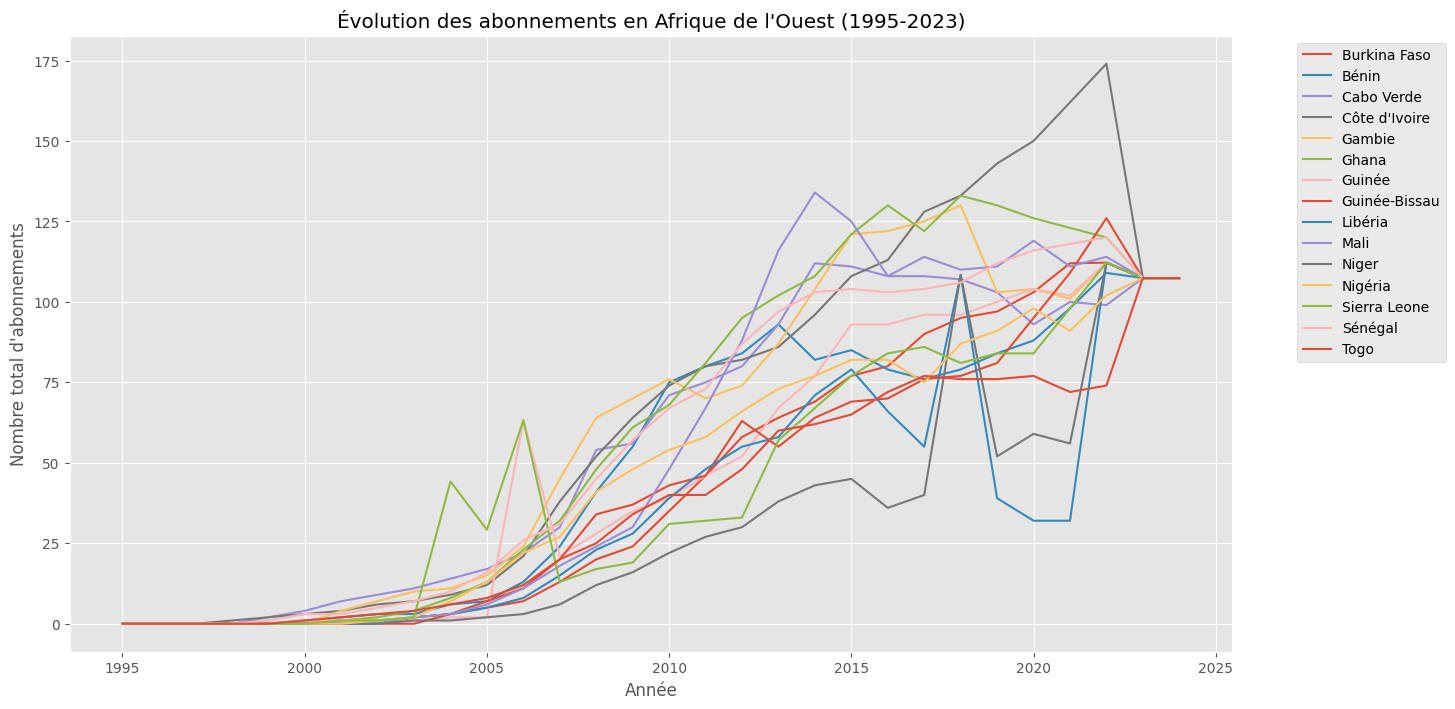

In [ ]:
import matplotlib.pyplot as plt

# Pivoter les données pour avoir les années en colonnes
df_pivot = df_afw.pivot_table(index='Country Name', columns='Year', values='Suscriber', aggfunc='sum')

# Tracer le graphique d'évolution
plt.figure(figsize=(15, 8))
for country in df_pivot.index:
    plt.plot(df_pivot.columns, df_pivot.loc[country], label=country)

plt.title('Évolution des abonnements en Afrique de l\'Ouest (1995-2023)')
plt.xlabel('Année')
plt.ylabel('Nombre total d\'abonnements')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()


In [ ]:
# Fusionner les données
world_subscribers = world.merge(total_subscribers_by_country, on='ISO_A3', how='inner')


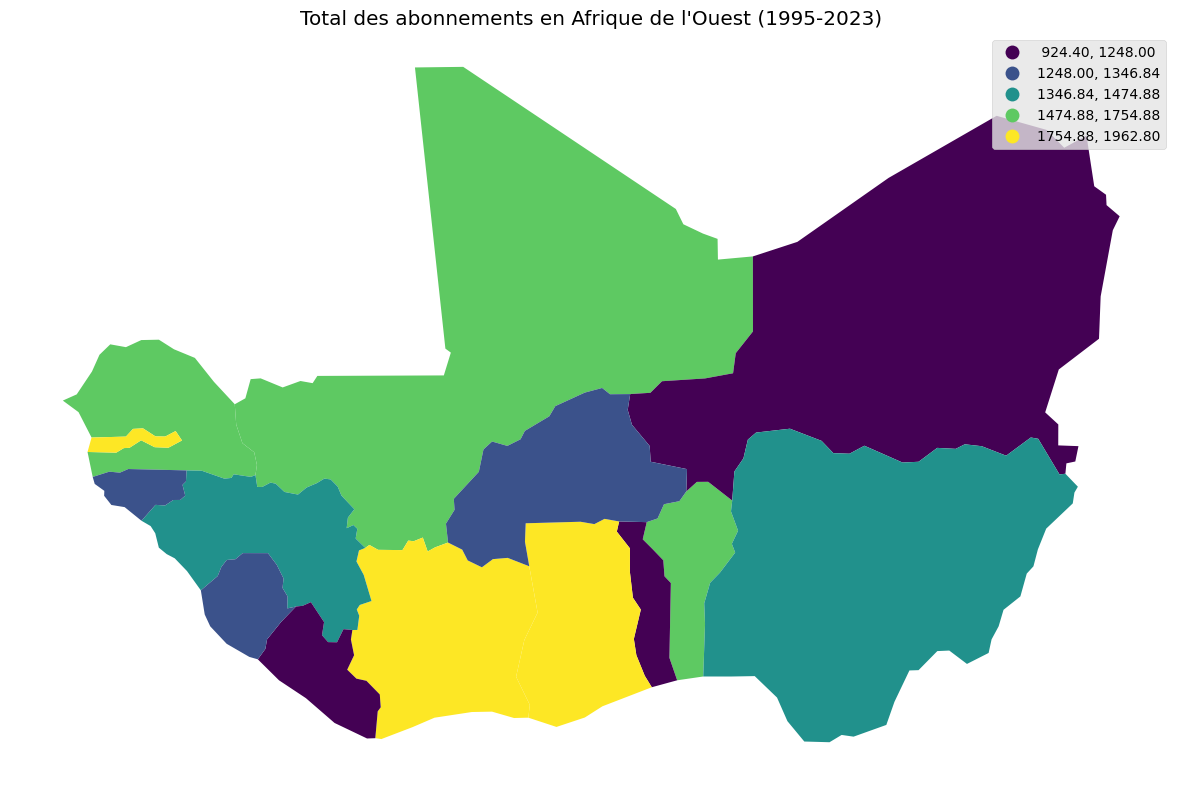

In [ ]:
import matplotlib.pyplot as plt

# Créer la carte
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
world_subscribers.plot(column='Suscriber', cmap='viridis', legend=True, ax=ax, scheme='quantiles', k=5)
ax.set_title('Total des abonnements en Afrique de l\'Ouest (1995-2023)')
ax.set_axis_off()
plt.show()


In [ ]:
import json
# Filtrer les données géographiques pour l'Afrique de l'Ouest
west_africa_geo = world[world['ISO_A3'].isin(west_africa_codes)]

# Fusionner les données
west_africa_subscribers = west_africa_geo.merge(total_subscribers_by_country, on='ISO_A3', how='inner')
# Convertir en GeoJSON
# Convertir en GeoJSON
geojson_data = json.loads(west_africa_subscribers.to_json())


In [ ]:
import plotly.express as px

# Créer la carte choroplèthe
fig = px.choropleth(
    west_africa_subscribers,
    geojson=geojson_data,
    locations='ISO_A3',
    color='Suscriber',
    hover_name='Country Name',
    color_continuous_scale="Viridis",
    title='Total des abonnements en Afrique de l\'Ouest (1995-2023)',
    labels={'Suscriber': 'Nombre total d\'abonnements'}
)

# Mettre à jour la mise en page de la carte
fig.update_geos(
    showcountries=True,
    showcoastlines=True,
    showland=True,
    fitbounds="locations",  # Centrer la carte sur les données
    visible=False  # Masquer le fond de carte global
)

# Afficher la carte
fig.show()


# **PARTIE III : MODELISATION DE LA SERIE TEMPORELLE**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving suscriber_civ.xlsx to suscriber_civ.xlsx


In [ ]:
df = pd.read_excel('suscriber_civ.xlsx')

In [ ]:
df.head()

,Années,Taux
0,2000-12-31,2.88
1,2001-12-31,4.30
2,2002-12-31,5.88
3,2003-12-31,7.11
4,2004-12-31,9.03


In [ ]:
df.info()

Construction de la série temporelle

In [ ]:
df['Années'] = pd.to_datetime(df['Années'])
df = df.set_index('Années')

In [ ]:
df.head()

,Taux
Années,
2000-12-31,2.88
2001-12-31,4.30
2002-12-31,5.88
2003-12-31,7.11
2004-12-31,9.03


None


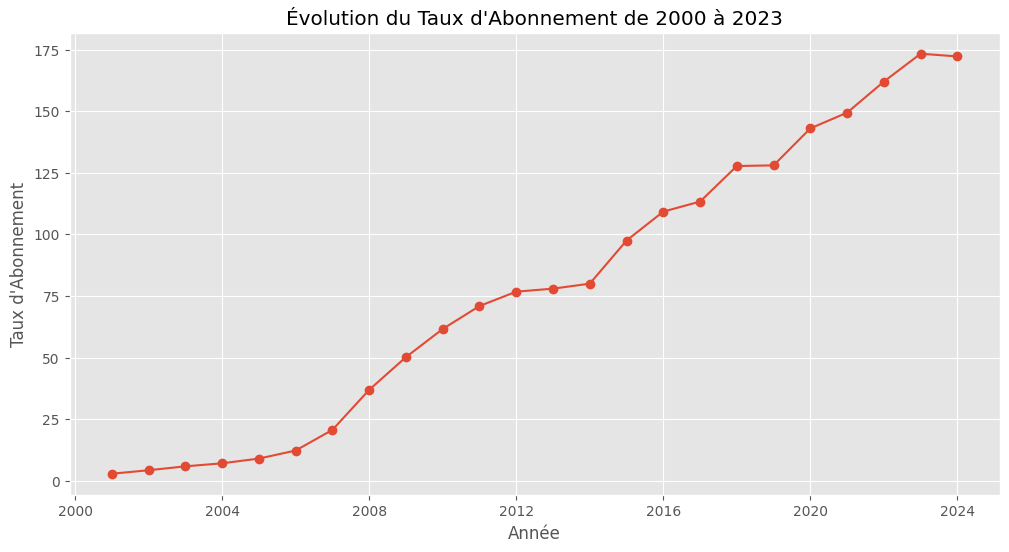

In [ ]:
print(df.index.freq)
df.head()

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Taux'], marker='o', linestyle='-')
plt.title('Évolution du Taux d\'Abonnement en CI de 2000 à 2023')
plt.xlabel('Année')
plt.ylabel('Taux d\'Abonnement')
plt.grid(True)
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Perform the ADF test on the 'Taux' column
result = adfuller(df['Taux'])

# Extract and print the results
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Number of lags used:', result[2])
print('Number of observations used:', result[3])
print('Critical Values:')
for key, value in result[4].items():
    print(f'\t{key}: {value}')

# Check for stationarity based on p-value
if result[1] <= 0.05:
    print("\nConclusion: The time series is likely stationary (p-value <= 0.05).")
else:
    print("\nConclusion: The time series is likely non-stationary (p-value > 0.05).")

ADF Statistic: 1.332048386125017
p-value: 0.9967824849696553
Number of lags used: 9
Number of observations used: 14
Critical Values:
	1%: -4.01203360058309
	5%: -3.1041838775510207
	10%: -2.6909873469387753

Conclusion: The time series is likely non-stationary (p-value > 0.05).


In [ ]:
df['Taux_diff'] = df['Taux'].diff().dropna()

print("First-order differenced series head:")
df.head()

First-order differenced series head:


,Taux,Taux_diff
Années,,
2000-12-31,2.88,NaN
2001-12-31,4.30,1.42
2002-12-31,5.88,1.58
2003-12-31,7.11,1.23
2004-12-31,9.03,1.92


In [ ]:
from statsmodels.tsa.stattools import adfuller

# Perform the ADF test on the differenced 'Taux_diff' column
result_diff = adfuller(df['Taux_diff'].dropna())

# Extract and print the results
print('ADF Statistic (Differenced):', result_diff[0])
print('p-value (Differenced):', result_diff[1])
print('Number of lags used (Differenced):', result_diff[2])
print('Number of observations used (Differenced):', result_diff[3])
print('Critical Values (Differenced):')
for key, value in result_diff[4].items():
    print(f'\t{key}: {value}')

# Check for stationarity based on p-value
if result_diff[1] <= 0.05:
    print("\nConclusion: The differenced time series is likely stationary (p-value <= 0.05).")
else:
    print("\nConclusion: The differenced time series is still non-stationary (p-value > 0.05).")

ADF Statistic (Differenced): -2.1793953212328865
p-value (Differenced): 0.21380857078855686
Number of lags used (Differenced): 8
Number of observations used (Differenced): 14
Critical Values (Differenced):
	1%: -4.01203360058309
	5%: -3.1041838775510207
	10%: -2.6909873469387753

Conclusion: The differenced time series is still non-stationary (p-value > 0.05).


In [ ]:
df['Taux_diff2'] = df['Taux'].diff().diff().dropna()

print("Second-order differenced series head:")
df.head()

Second-order differenced series head:


,Taux,Taux_diff,Taux_diff2
Années,,,
2000-12-31,2.88,NaN,NaN
2001-12-31,4.30,1.42,NaN
2002-12-31,5.88,1.58,0.16
2003-12-31,7.11,1.23,-0.35
2004-12-31,9.03,1.92,0.69


In [ ]:
from statsmodels.tsa.stattools import adfuller

# Perform the ADF test on the second-order differenced 'Taux_diff2' column
result_diff2 = adfuller(df['Taux_diff2'].dropna())

# Extract and print the results
print('ADF Statistic (Second-order Differenced):', result_diff2[0])
print('p-value (Second-order Differenced):', result_diff2[1])
print('Number of lags used (Second-order Differenced):', result_diff2[2])
print('Number of observations used (Second-order Differenced):', result_diff2[3])
print('Critical Values (Second-order Differenced):')
for key, value in result_diff2[4].items():
    print(f'\t{key}: {value}')

# Check for stationarity based on p-value
if result_diff2[1] <= 0.05:
    print("\nConclusion: The second-order differenced time series is likely stationary (p-value <= 0.05).")
else:
    print("\nConclusion: The second-order differenced time series is still non-stationary (p-value > 0.05).")

ADF Statistic (Second-order Differenced): -2.1877273653258023
p-value (Second-order Differenced): 0.21072982974581927
Number of lags used (Second-order Differenced): 8
Number of observations used (Second-order Differenced): 13
Critical Values (Second-order Differenced):
	1%: -4.068853732362312
	5%: -3.1271488757396453
	10%: -2.7017297633136095

Conclusion: The second-order differenced time series is still non-stationary (p-value > 0.05).


In [ ]:
df['Taux_diff3'] = df['Taux'].diff().diff().diff().dropna()

print("Third-order differenced series head:")
df.head()

Third-order differenced series head:


,Taux,Taux_diff,Taux_diff2,Taux_diff3
Années,,,,
2000-12-31,2.88,NaN,NaN,NaN
2001-12-31,4.30,1.42,NaN,NaN
2002-12-31,5.88,1.58,0.16,NaN
2003-12-31,7.11,1.23,-0.35,-0.51
2004-12-31,9.03,1.92,0.69,1.04


In [ ]:
from statsmodels.tsa.stattools import adfuller

# Perform the ADF test on the third-order differenced 'Taux_diff3' column
result_diff3 = adfuller(df['Taux_diff3'].dropna())

# Extract and print the results
print('ADF Statistic (Third-order Differenced):', result_diff3[0])
print('p-value (Third-order Differenced):', result_diff3[1])
print('Number of lags used (Third-order Differenced):', result_diff3[2])
print('Number of observations used (Third-order Differenced):', result_diff3[3])
print('Critical Values (Third-order Differenced):')
for key, value in result_diff3[4].items():
    print(f'\t{key}: {value}')

# Check for stationarity based on p-value
if result_diff3[1] <= 0.05:
    print("\nConclusion: The third-order differenced time series is likely stationary (p-value <= 0.05).")
else:
    print("\nConclusion: The third-order differenced time series is still non-stationary (p-value > 0.05).")

ADF Statistic (Third-order Differenced): -3.83500073067699
p-value (Third-order Differenced): 0.0025688410085718868
Number of lags used (Third-order Differenced): 5
Number of observations used (Third-order Differenced): 15
Critical Values (Third-order Differenced):
	1%: -3.9644434814814815
	5%: -3.0849081481481484
	10%: -2.6818144444444445

Conclusion: The third-order differenced time series is likely stationary (p-value <= 0.05).


Graphiques ACF and PACF


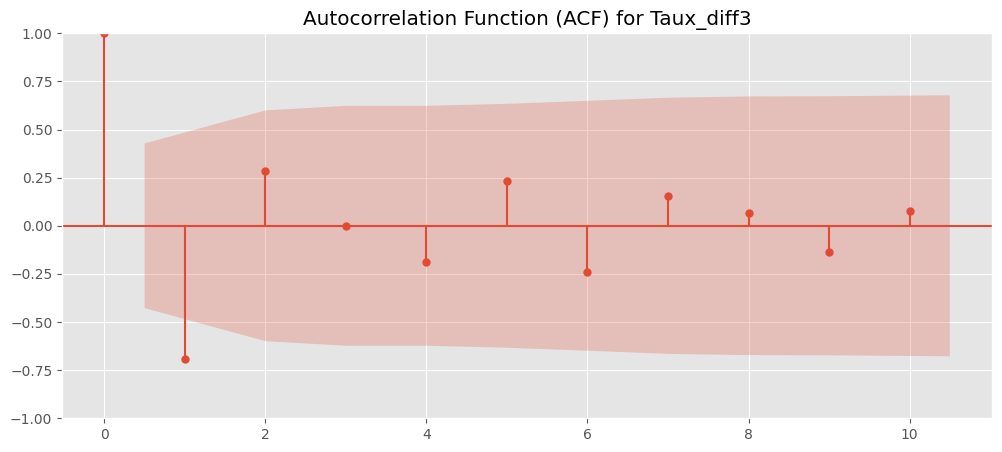

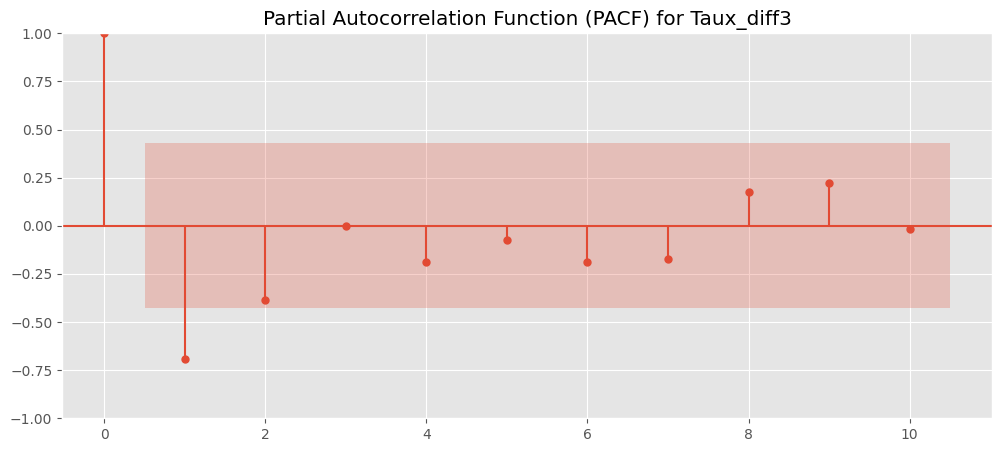

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Create ACF plot for Taux_diff3
plt.figure(figsize=(12, 5))
plot_acf(df['Taux_diff3'].dropna(), lags=10, ax=plt.gca(), title='Autocorrelation Function (ACF) for Taux_diff3')
plt.grid(True)
plt.show()

# Create PACF plot for Taux_diff3
plt.figure(figsize=(12, 5))
plot_pacf(df['Taux_diff3'].dropna(), lags=10, ax=plt.gca(), title='Partial Autocorrelation Function (PACF) for Taux_diff3')
plt.grid(True)
plt.show()

Fit ARIMA Model



In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Define the ARIMA model order (p, d, q)
# d = 3 (from previous stationarity tests)
# p = 1 (from PACF of Taux_diff3, significant spike at lag 1)
# q = 1 (from ACF of Taux_diff3, significant spike at lag 1)
arima_order = (1, 3, 1)

# Instantiate the ARIMA model
# Use the original 'Taux' column and drop any NaN values
model = ARIMA(df['Taux'].dropna(), order=arima_order)

# Fit the ARIMA model
model_fit = model.fit()

# Print the model summary
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                   Taux   No. Observations:                   24
Model:                 ARIMA(1, 3, 1)   Log Likelihood                 -71.964
Date:                Sun, 28 Dec 2025   AIC                            149.929
Time:                        03:03:58   BIC                            153.062
Sample:                    12-31-2000   HQIC                           150.609
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4751      0.252     -1.882      0.060      -0.970       0.020
ma.L1         -0.9993     39.467     -0.025      0.980     -78.353      76.354
sigma2        45.6772   1800.931      0.025      0.9

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Ensure the DataFrame index has a frequency
# Based on the data (yearly, ending in December), 'YE-DEC' is appropriate.
df.index.freq = 'YE-DEC'

# Define the ARIMA model order (p, d, q)
# d = 3 (from previous stationarity tests)
# p = 1 (from PACF of Taux_diff3, significant spike at lag 1)
# q = 1 (from ACF of Taux_diff3, significant spike at lag 1)
arima_order = (1, 3, 1)

# Instantiate the ARIMA model
# Use the original 'Taux' column and drop any NaN values
model = ARIMA(df['Taux'].dropna(), order=arima_order)

# Fit the ARIMA model
model_fit = model.fit()

# Print the model summary
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   Taux   No. Observations:                   24
Model:                 ARIMA(1, 3, 1)   Log Likelihood                 -71.964
Date:                Sun, 28 Dec 2025   AIC                            149.929
Time:                        03:04:15   BIC                            153.062
Sample:                    12-31-2000   HQIC                           150.609
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4751      0.252     -1.882      0.060      -0.970       0.020
ma.L1         -0.9993     39.467     -0.025      0.980     -78.353      76.354
sigma2        45.6772   1800.931      0.025      0.9

Evaluation du  Modele ARIMA



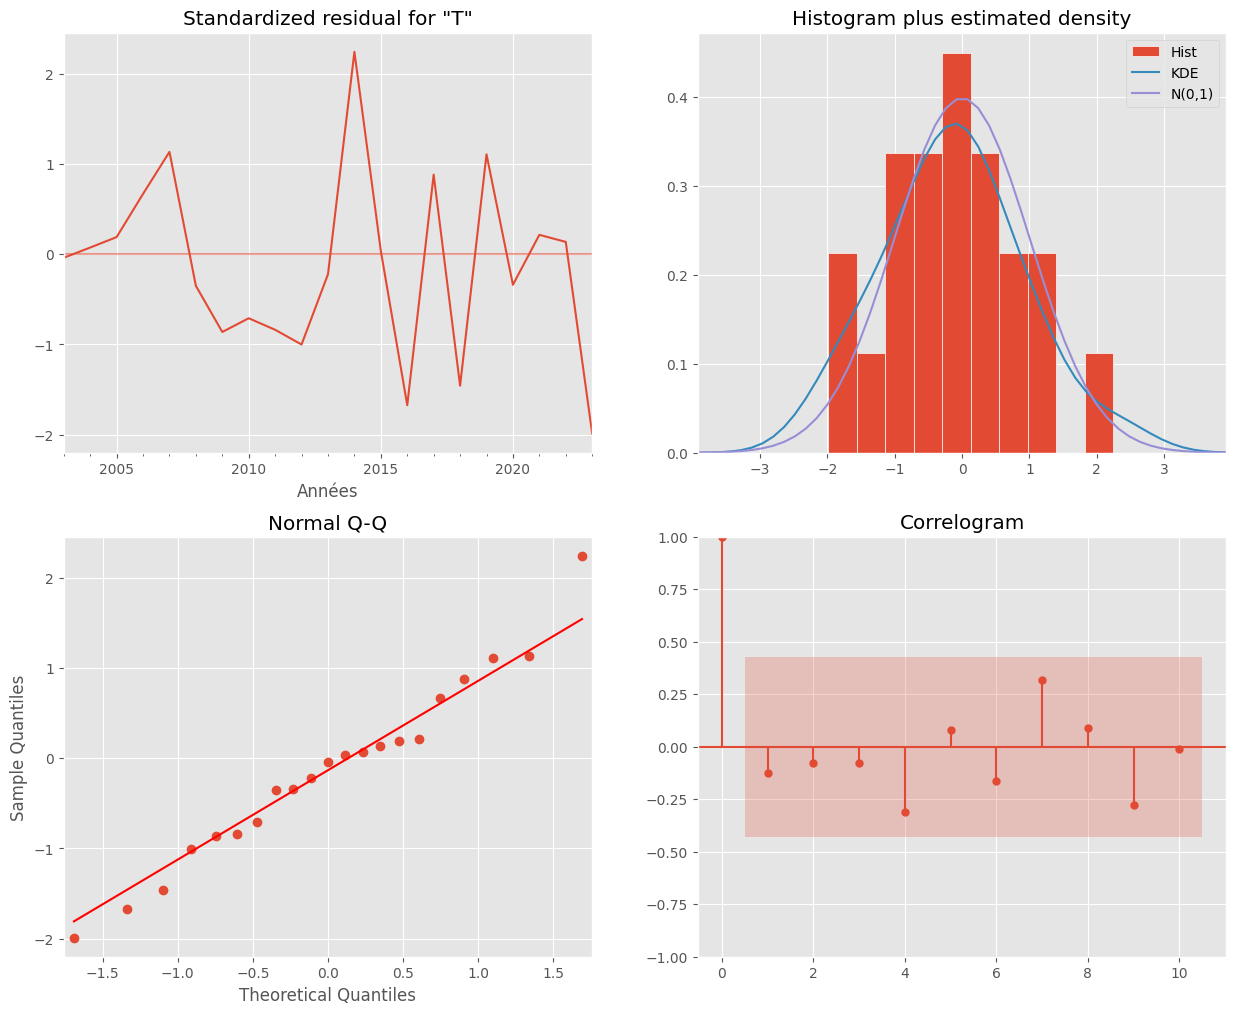

In [ ]:
import matplotlib.pyplot as plt

# Plot the diagnostics of the fitted ARIMA model
model_fit.plot_diagnostics(figsize=(15, 12))
plt.show()

Evaluation de modeles salternatifs ARIMA


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# 1. Define a list of (p, q) tuples representing different AR and MA orders to test
pq_combinations = [(0, 1), (1, 0), (1, 1), (2, 1), (1, 2), (2, 2)]

# 2. Create an empty dictionary to store the fitted models and their AIC/BIC values
arima_models = {}

# Ensure the DataFrame index has a frequency set
df.index.freq = 'YE-DEC'

# 3. Loop through each (p, q) combination
for p, q in pq_combinations:
    # a. Construct the full ARIMA order (d is fixed at 3)
    arima_order = (p, 3, q)
    print(f"\nFitting ARIMA{arima_order} model...")

    try:
        # b. Instantiate an ARIMA model using df['Taux'].dropna() and the current ARIMA order
        model = ARIMA(df['Taux'].dropna(), order=arima_order)

        # c. Fit the model and store the fitted model object
        model_fit = model.fit()
        arima_models[(p, q)] = model_fit

        # d. Print the summary for each fitted model
        print(model_fit.summary())
    except Exception as e:
        print(f"Could not fit ARIMA{arima_order} model: {e}")



Fitting ARIMA(0, 3, 1) model...
                               SARIMAX Results                                
Dep. Variable:                   Taux   No. Observations:                   24
Model:                 ARIMA(0, 3, 1)   Log Likelihood                 -74.360
Date:                Sun, 28 Dec 2025   AIC                            152.719
Time:                        03:10:12   BIC                            154.808
Sample:                    12-31-2000   HQIC                           153.172
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9988     27.563     -0.036      0.971     -55.021      53.023
sigma2        60.2154   1660.132      0.036      0.971   -3193.583    3314.014
Ljung-Box (L1) (Q):

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:                   Taux   No. Observations:                   24
Model:                 ARIMA(2, 3, 1)   Log Likelihood                 -71.785
Date:                Sun, 28 Dec 2025   AIC                            151.570
Time:                        03:10:12   BIC                            155.748
Sample:                    12-31-2000   HQIC                           152.477
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5595      0.370     -1.511      0.131      -1.285       0.166
ar.L2         -0.1412      0.333     -0.424      0.672      -0.794       0.512
ma.L1         -0.9995     48.095     -0.021      0.9

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:                   Taux   No. Observations:                   24
Model:                 ARIMA(2, 3, 2)   Log Likelihood                 -70.895
Date:                Sun, 28 Dec 2025   AIC                            151.790
Time:                        03:10:13   BIC                            157.012
Sample:                    12-31-2000   HQIC                           152.923
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.4086      0.594     -2.371      0.018      -2.573      -0.244
ar.L2         -0.6077      0.255     -2.383      0.017      -1.107      -0.108
ma.L1         -0.1328     88.541     -0.002      0.9

In [ ]:
print("\n--- Model Comparison ---")

# Evaluate and compare models based on AIC and BIC
best_aic = float('inf')
best_bic = float('inf')
best_model_aic = None
best_model_bic = None

print("| Model Order | AIC        | BIC        |")
print("|-------------|------------|------------|")
for order, model_fit in arima_models.items():
    aic = model_fit.aic
    bic = model_fit.bic
    print(f"| ARIMA{order}    | {aic:.2f}     | {bic:.2f}     |")

    if aic < best_aic:
        best_aic = aic
        best_model_aic = order

    if bic < best_bic:
        best_bic = bic
        best_model_bic = order

print(f"\nBest model by AIC: ARIMA{best_model_aic} (AIC: {best_aic:.2f})")
print(f"Best model by BIC: ARIMA{best_model_bic} (BIC: {best_bic:.2f})")

print("\n--- Further Analysis of Best Models ---")
if best_model_aic:
    print(f"\nSummary for Best Model (AIC): ARIMA{best_model_aic}")
    print(arima_models[best_model_aic].summary())

if best_model_bic and best_model_aic != best_model_bic:
    print(f"\nSummary for Best Model (BIC): ARIMA{best_model_bic}")
    print(arima_models[best_model_bic].summary())

# You can also manually inspect specific models
# For example, to check the diagnostics of a specific model:
# arima_models[(1,1)].plot_diagnostics(figsize=(15, 12))
# plt.show()


--- Model Comparison ---
| Model Order | AIC        | BIC        |
|-------------|------------|------------|
| ARIMA(0, 1)    | 152.72     | 154.81     |
| ARIMA(1, 0)    | 157.55     | 159.63     |
| ARIMA(1, 1)    | 149.93     | 153.06     |
| ARIMA(2, 1)    | 151.57     | 155.75     |
| ARIMA(1, 2)    | 150.53     | 154.71     |
| ARIMA(2, 2)    | 151.79     | 157.01     |

Best model by AIC: ARIMA(1, 1) (AIC: 149.93)
Best model by BIC: ARIMA(1, 1) (BIC: 153.06)

--- Further Analysis of Best Models ---

Summary for Best Model (AIC): ARIMA(1, 1)
                               SARIMAX Results                                
Dep. Variable:                   Taux   No. Observations:                   24
Model:                 ARIMA(1, 3, 1)   Log Likelihood                 -71.964
Date:                Sun, 28 Dec 2025   AIC                            149.929
Time:                        03:10:31   BIC                            153.062
Sample:                    12-31-2000   HQIC      

### Resultats:

| Modeles | AIC        | BIC        |
|-------------|------------|------------|
| ARIMA(0, 3, 1) | 152.72     | 154.81     |
| ARIMA(1, 3, 0) | 157.55     | 159.63     |
| ARIMA(1, 3, 1) | **149.93** | **153.06** |
| ARIMA(2, 3, 1) | 151.57     | 155.75     |
| ARIMA(1, 3, 2) | 150.53     | 154.71     |
| ARIMA(2, 3, 2) | 151.79     | 157.01     |



## Test de Ljung-Box  sur les residus



In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Retrieve the best model (ARIMA(1,3,1)) from the arima_models dictionary
best_arima_model_fit = arima_models[best_model_aic]

# Get the residuals from the fitted model
residuals = best_arima_model_fit.resid

# Perform the Ljung-Box test on the residuals
# We check for autocorrelation at several lags, e.g., 1, 5, 10
# The parameter 'return_df=True' makes the output a DataFrame for easier handling.
# 'boxpierce' or 'ljungbox' specifies the type of test, 'ljungbox' is common for ARIMA.
ljung_box_results = acorr_ljungbox(residuals, lags=[1, 5, 10], return_df=True)

print("\nLjung-Box Test Results on Residuals (for ARIMA(1,3,1) model):\n")
print(ljung_box_results)

# Interpret the results, focusing on the p-values
# A p-value > 0.05 suggests that residuals are white noise (no significant autocorrelation)
print("\nInterpretation of Ljung-Box p-values:")
for lag, row in ljung_box_results.iterrows():
    p_value = row['lb_pvalue']
    if p_value > 0.05:
        print(f"  Lag {lag}: p-value = {p_value:.3f} > 0.05. Residuals are white noise at this lag.")
    else:
        print(f"  Lag {lag}: p-value = {p_value:.3f} <= 0.05. Residuals show significant autocorrelation at this lag. Model might be inadequate.")



Ljung-Box Test Results on Residuals (for ARIMA(1,3,1) model):

      lb_stat  lb_pvalue
1    0.337746   0.561133
5    3.720611   0.590300
10  12.683041   0.241937

Interpretation of Ljung-Box p-values:
  Lag 1: p-value = 0.561 > 0.05. Residuals are white noise at this lag.
  Lag 5: p-value = 0.590 > 0.05. Residuals are white noise at this lag.
  Lag 10: p-value = 0.242 > 0.05. Residuals are white noise at this lag.


### Resume du Test Ljung-Box



**Resultats:**

| Lag | Ljung-Box Statistic | p-value |
|-----|---------------------|---------|
| 1   | 0.3377              | 0.561   |
| 5   | 3.7206              | 0.590   |
| 10  | 12.6830             | 0.242   |


## Test de normalite sur les residus



In [ ]:
from scipy.stats import jarque_bera

# Get the residuals from the fitted model (best_arima_model_fit is already defined from previous steps)
residuals = best_arima_model_fit.resid

# Perform the Jarque-Bera test on the residuals
jb_test_results = jarque_bera(residuals)

print("\nJarque-Bera Test Results on Residuals (for ARIMA(1,3,1) model):\n")
print(f"JB Statistic: {jb_test_results[0]:.3f}")
print(f"p-value: {jb_test_results[1]:.3f}")
# Removed printing skewness and kurtosis directly from jb_test_results as they are not returned by the function

# Interpret the results based on the p-value
if jb_test_results[1] > 0.05:
    print("\nConclusion: Residuals appear to be normally distributed (p-value > 0.05).")
else:
    print("\nConclusion: Residuals do not appear to be normally distributed (p-value <= 0.05).")


Jarque-Bera Test Results on Residuals (for ARIMA(1,3,1) model):

JB Statistic: 0.223
p-value: 0.895

Conclusion: Residuals appear to be normally distributed (p-value > 0.05).


## test d'heteroscedasticite des residus


In [ ]:
from statsmodels.stats.diagnostic import het_arch

# Get the residuals from the fitted model
residuals = best_arima_model_fit.resid

# Perform the ARCH test on the residuals
# We will use 5 lags for this test.
arch_test_results = het_arch(residuals, nlags=5)

# The het_arch function returns a tuple: (LM statistic, p-value, F statistic, F p-value)
# We are primarily interested in the p-value for the LM statistic.

print("\nARCH Test Results on Residuals (for ARIMA(1,3,1) model):\n")
print(f"LM Statistic: {arch_test_results[0]:.3f}")
print(f"LM p-value: {arch_test_results[1]:.3f}")
print(f"F Statistic: {arch_test_results[2]:.3f}")
print(f"F p-value: {arch_test_results[3]:.3f}")

# Interpret the results based on the p-value
alpha = 0.05 # Significance level
if arch_test_results[1] < alpha:
    print(f"\nConclusion: Residuals show evidence of heteroskedasticity (LM p-value < {alpha}).")
else:
    print(f"\nConclusion: Residuals do not show significant evidence of heteroskedasticity (LM p-value >= {alpha}).")


ARCH Test Results on Residuals (for ARIMA(1,3,1) model):

LM Statistic: 3.846
LM p-value: 0.572
F Statistic: 0.660
F p-value: 0.660

Conclusion: Residuals do not show significant evidence of heteroskedasticity (LM p-value >= 0.05).


## Prevision des valeurs futures



In [ ]:
import pandas as pd

# 1. Define the number of future periods (e.g., 5 years)
n_forecast_steps = 5

# Get the last date in the existing DataFrame index
last_date = df.index[-1]

# Generate future dates for forecasting
# Since the data is yearly ('YE-DEC'), add n_forecast_steps years to the last date
forecast_index = pd.date_range(start=last_date, periods=n_forecast_steps + 1, freq='YE-DEC')[1:]

# 2. Use the get_forecast() method to generate forecasts
# The `steps` parameter defines how many future steps to forecast.
forecast_results = best_arima_model_fit.get_forecast(steps=n_forecast_steps)

# 3. Extract the predicted mean and the confidence intervals
predicted_mean = forecast_results.predicted_mean
conf_int = forecast_results.conf_int()

print("Forecasted Mean:")
print(predicted_mean)
print("\nConfidence Intervals:")
print(conf_int)


Forecasted Mean:
2024-12-31    177.089549
2025-12-31    179.231608
2026-12-31    182.777221
2027-12-31    185.754191
2028-12-31    189.099527
Freq: YE-DEC, Name: predicted_mean, dtype: float64

Confidence Intervals:
            lower Taux  upper Taux
2024-12-31  163.541151  190.637947
2025-12-31  154.023860  204.439355
2026-12-31  141.786424  223.768018
2027-12-31  126.811329  244.697053
2028-12-31  109.546177  268.652876


## Graphique sur les valeurs predites


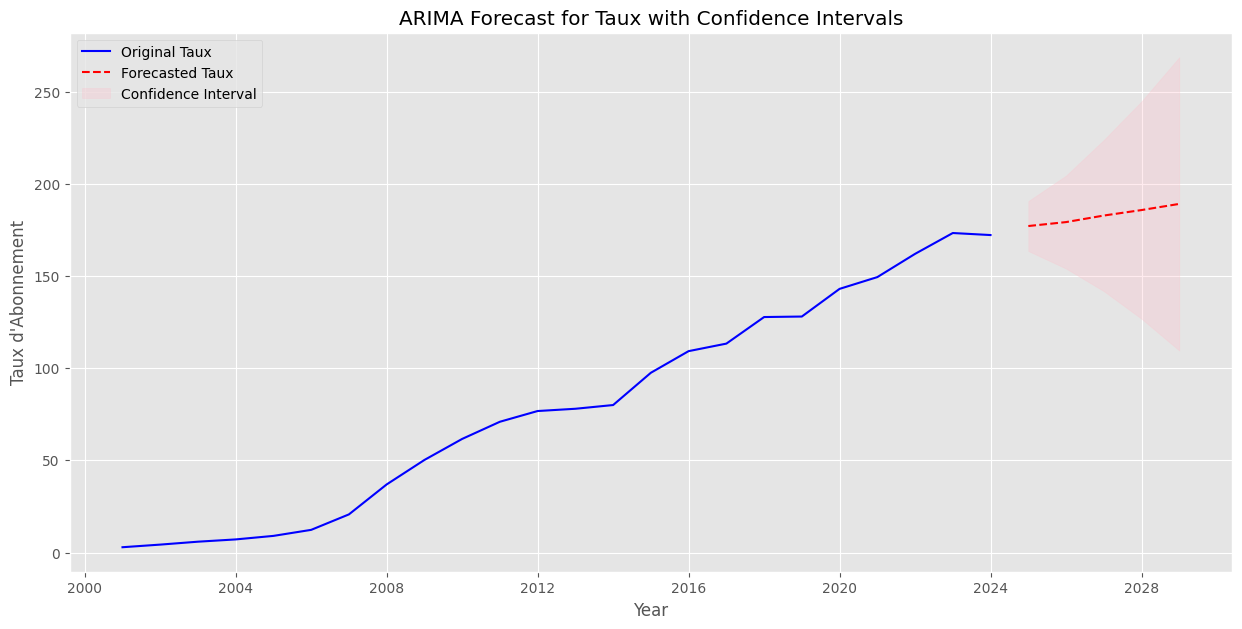

In [ ]:
import matplotlib.pyplot as plt

# Plot the original series
plt.figure(figsize=(15, 7))
plt.plot(df.index, df['Taux'], label='Original Taux', color='blue')

# Plot the forecasted mean
plt.plot(predicted_mean.index, predicted_mean, label='Forecasted Taux', color='red', linestyle='--')

# Plot the confidence intervals
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3, label='Confidence Interval')

plt.title('ARIMA Forecast for Taux with Confidence Intervals')
plt.xlabel('Year')
plt.ylabel('Taux d\'Abonnement')
plt.legend()
plt.grid(True)
plt.show()